# Model Training and Hyperparameter Tuning

This notebook trains four classifiers on the merged feature dataset and then tunes the two best-performing ones.

**Classifiers:**
- Decision Tree
- Random Forest
- XGBoost
- k-Nearest Neighbors (k-NN)

**Plan:**
1. Load data, split 80/20, analyse class imbalance
2. Train all four models with default parameters
3. Test multiple k values for k-NN
4. Run RandomizedSearchCV on Random Forest and XGBoost
5. Save the best models to `models/`

All results are reported on the held-out test set. Hyperparameter search uses 5-fold stratified cross-validation on the training set only.

## 1. Setup

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing    import StandardScaler
from sklearn.tree             import DecisionTreeClassifier, export_text
from sklearn.ensemble         import RandomForestClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                      f1_score, roc_auc_score, classification_report)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
FIG_DIR      = '../figures'
MODELS_DIR   = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Load Data

In [2]:
df = pd.read_csv('../data/processed/merged_features.csv', parse_dates=['date'])

feature_cols = [c for c in df.columns
                if c not in ['machineID', 'date', 'failure_within_24h', 'failure_component']]

X = df[feature_cols]
y = df['failure_within_24h']

print(f'Dataset shape  : {df.shape}')
print(f'Feature count  : {len(feature_cols)}')
print(f'Positive class : {y.sum()} ({y.mean()*100:.2f}%)')
print(f'Negative class : {(y==0).sum()} ({(y==0).mean()*100:.2f}%)')

Dataset shape  : (36600, 65)
Feature count  : 61
Positive class : 718 (1.96%)
Negative class : 35882 (98.04%)


## 3. Train / Test Split

80% training, 20% test. Stratified split preserves the class ratio in both sets.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} rows  ({y_train.sum()} positives)')
print(f'Test : {X_test.shape[0]:,} rows  ({y_test.sum()} positives)')
print()
print(f'Class imbalance in train set: {y_train.value_counts()[0]//y_train.value_counts()[1]}:1 (neg:pos)')

# scale_pos_weight for XGBoost: ratio of negatives to positives
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'XGBoost scale_pos_weight: {scale_pos_weight:.1f}')

Train: 29,280 rows  (574 positives)
Test : 7,320 rows  (144 positives)

Class imbalance in train set: 50:1 (neg:pos)
XGBoost scale_pos_weight: 50.0


## 4. Feature Scaling

Tree-based models (Decision Tree, Random Forest, XGBoost) are scale-invariant, so scaling does not affect them. k-NN uses Euclidean distance and is sensitive to feature scale, so it receives standardised features.

The scaler is fit on the training set only and then applied to the test set to avoid data leakage.

In [4]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaler fit on training set.')
print(f'  Mean of first feature (train): {X_train_sc[:, 0].mean():.4f}')
print(f'  Std  of first feature (train): {X_train_sc[:, 0].std():.4f}')

Scaler fit on training set.
  Mean of first feature (train): -0.0000
  Std  of first feature (train): 1.0000


## 5. Baseline Models

Each model is trained with default parameters first. This establishes a baseline before any tuning.

In [5]:
def evaluate(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    prob = clf.predict_proba(X_te)[:, 1]
    return {
        'model':     name,
        'accuracy':  round(accuracy_score(y_te, pred),  4),
        'precision': round(precision_score(y_te, pred, zero_division=0), 4),
        'recall':    round(recall_score(y_te, pred, zero_division=0), 4),
        'f1':        round(f1_score(y_te, pred, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_te, prob), 4),
    }, clf

baseline_models = [
    ('DecisionTree', DecisionTreeClassifier(random_state=RANDOM_STATE),              X_train,    X_test),
    ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), X_train, X_test),
    ('XGBoost',      XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                                   eval_metric='logloss', n_jobs=-1, verbosity=0),   X_train,    X_test),
    ('kNN (k=5)',    KNeighborsClassifier(n_neighbors=5),                            X_train_sc, X_test_sc),
]

baseline_results = []
trained_baseline = {}
for name, clf, Xtr, Xte in baseline_models:
    print(f'Training {name}...')
    result, fitted = evaluate(name, clf, Xtr, y_train, Xte, y_test)
    baseline_results.append(result)
    trained_baseline[name] = fitted

baseline_df = pd.DataFrame(baseline_results).set_index('model')
print()
print('Baseline Results:')
display(baseline_df)

Training DecisionTree...


Training RandomForest...


Training XGBoost...


Training kNN (k=5)...



Baseline Results:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
DecisionTree,0.9980,0.9388,0.9583,0.9485,0.9785
RandomForest,0.9988,0.9592,0.9792,0.9691,1.0000
XGBoost,0.9988,0.9470,0.9931,0.9695,0.9999
kNN (k=5),0.9978,0.9051,0.9931,0.9470,0.9997


## 6. Decision Tree: Depth vs. Performance

An unconstrained decision tree can overfit. Testing different `max_depth` values shows the trade-off between model complexity and generalisation.

,f1,precision,recall,roc_auc
max_depth,,,,
3,0.7304,0.9767,0.5833,0.8818
5,0.9408,0.9441,0.9375,0.9694
7,0.9431,0.9097,0.9792,0.9858
10,0.9452,0.9324,0.9583,0.9785
15,0.9485,0.9388,0.9583,0.9785
20,0.9485,0.9388,0.9583,0.9785
None,0.9485,0.9388,0.9583,0.9785


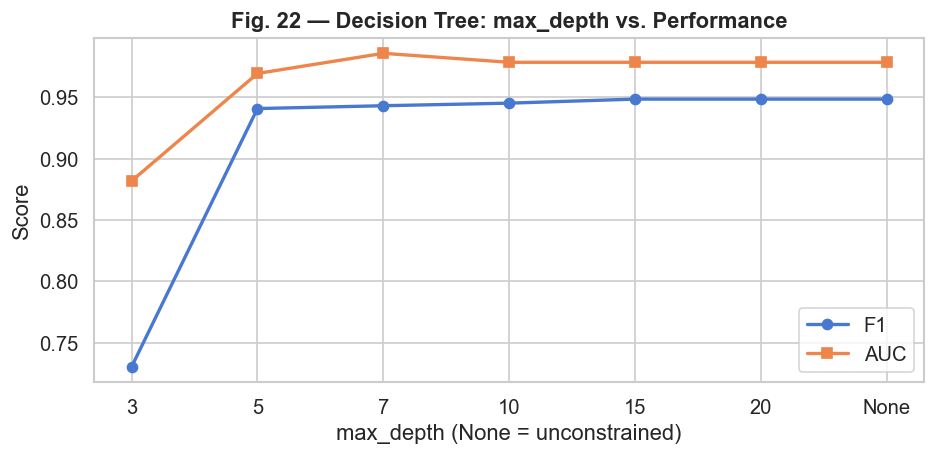

In [6]:
depths = [3, 5, 7, 10, 15, 20, None]
dt_depth_results = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    prob = clf.predict_proba(X_test)[:, 1]
    dt_depth_results.append({
        'max_depth':  str(depth),
        'f1':         round(f1_score(y_test, pred, zero_division=0), 4),
        'precision':  round(precision_score(y_test, pred, zero_division=0), 4),
        'recall':     round(recall_score(y_test, pred, zero_division=0), 4),
        'roc_auc':    round(roc_auc_score(y_test, prob), 4),
    })

dt_depth_df = pd.DataFrame(dt_depth_results).set_index('max_depth')
display(dt_depth_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dt_depth_df.index, dt_depth_df['f1'],      marker='o', linewidth=2, label='F1')
ax.plot(dt_depth_df.index, dt_depth_df['roc_auc'], marker='s', linewidth=2, label='AUC')
ax.set_xlabel('max_depth (None = unconstrained)')
ax.set_ylabel('Score')
ax.set_title('Fig. 22 — Decision Tree: max_depth vs. Performance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/dt_depth_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. k-NN: k Value Sweep

Smaller k makes the decision boundary more local and sensitive to noise. Larger k smooths it out but may miss local patterns. We test k = 3, 5, 7, 11, 15, 21.

,f1,precision,recall,roc_auc
k,,,,
3,0.9404,0.8987,0.9861,0.9994
5,0.9470,0.9051,0.9931,0.9997
7,0.9502,0.9108,0.9931,0.9997
11,0.9502,0.9108,0.9931,0.9997
15,0.9502,0.9108,0.9931,0.9997
21,0.9470,0.9051,0.9931,0.9998


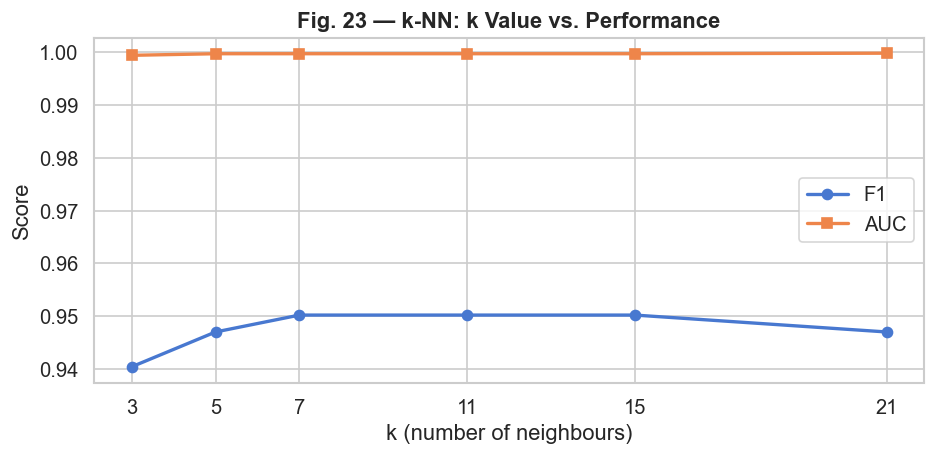

Best k by F1: 7


In [7]:
k_values = [3, 5, 7, 11, 15, 21]
knn_results = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    pred = clf.predict(X_test_sc)
    prob = clf.predict_proba(X_test_sc)[:, 1]
    knn_results.append({
        'k':          k,
        'f1':         round(f1_score(y_test, pred, zero_division=0), 4),
        'precision':  round(precision_score(y_test, pred, zero_division=0), 4),
        'recall':     round(recall_score(y_test, pred, zero_division=0), 4),
        'roc_auc':    round(roc_auc_score(y_test, prob), 4),
    })

knn_df = pd.DataFrame(knn_results).set_index('k')
display(knn_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(knn_df.index, knn_df['f1'],      marker='o', linewidth=2, label='F1')
ax.plot(knn_df.index, knn_df['roc_auc'], marker='s', linewidth=2, label='AUC')
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('Score')
ax.set_title('Fig. 23 — k-NN: k Value vs. Performance', fontweight='bold')
ax.set_xticks(k_values)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/knn_k_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

best_k = knn_df['f1'].idxmax()
print(f'Best k by F1: {best_k}')

## 8. Hyperparameter Tuning

Random Forest and XGBoost showed the strongest baseline performance. We run RandomizedSearchCV on both using 5-fold stratified cross-validation, optimising for F1.

RandomizedSearchCV samples `n_iter` random combinations from the parameter grid rather than exhaustively testing all of them. This gives a reasonable search at a fraction of the cost of GridSearchCV.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest ---
rf_param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'max_features':    ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'class_weight':    ['balanced', None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, n_iter=20, scoring='f1',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
print('Tuning Random Forest...')
rf_search.fit(X_train, y_train)

print(f'Best CV F1 : {rf_search.best_score_:.4f}')
print(f'Best params: {rf_search.best_params_}')

Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best CV F1 : 0.9729
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': None}


In [9]:
# --- XGBoost ---
xgb_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7],
    'learning_rate':     [0.05, 0.1, 0.2],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                  eval_metric='logloss', n_jobs=-1, verbosity=0),
    xgb_param_grid, n_iter=20, scoring='f1',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
print('Tuning XGBoost...')
xgb_search.fit(X_train, y_train)

print(f'Best CV F1 : {xgb_search.best_score_:.4f}')
print(f'Best params: {xgb_search.best_params_}')

Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best CV F1 : 0.9736
Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


## 9. Tuned Model Performance

In [10]:
tuned_results = []
tuned_models  = {}

for name, search in [('RandomForest (tuned)', rf_search), ('XGBoost (tuned)', xgb_search)]:
    best = search.best_estimator_
    pred = best.predict(X_test)
    prob = best.predict_proba(X_test)[:, 1]
    tuned_results.append({
        'model':     name,
        'accuracy':  round(accuracy_score(y_test, pred),  4),
        'precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'recall':    round(recall_score(y_test, pred, zero_division=0), 4),
        'f1':        round(f1_score(y_test, pred, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_test, prob), 4),
    })
    tuned_models[name] = best

tuned_df = pd.DataFrame(tuned_results).set_index('model')
print('Tuned Model Results:')
display(tuned_df)

Tuned Model Results:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
RandomForest (tuned),0.9989,0.9658,0.9792,0.9724,0.9999
XGBoost (tuned),0.9986,0.9408,0.9931,0.9662,1.0000


## 10. All Models — Combined Comparison Table

All models ranked by F1:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
RandomForest (tuned),0.9989,0.9658,0.9792,0.9724,0.9999
XGBoost,0.9988,0.9470,0.9931,0.9695,0.9999
RandomForest,0.9988,0.9592,0.9792,0.9691,1.0000
XGBoost (tuned),0.9986,0.9408,0.9931,0.9662,1.0000
DecisionTree,0.9980,0.9388,0.9583,0.9485,0.9785
kNN (k=5),0.9978,0.9051,0.9931,0.9470,0.9997


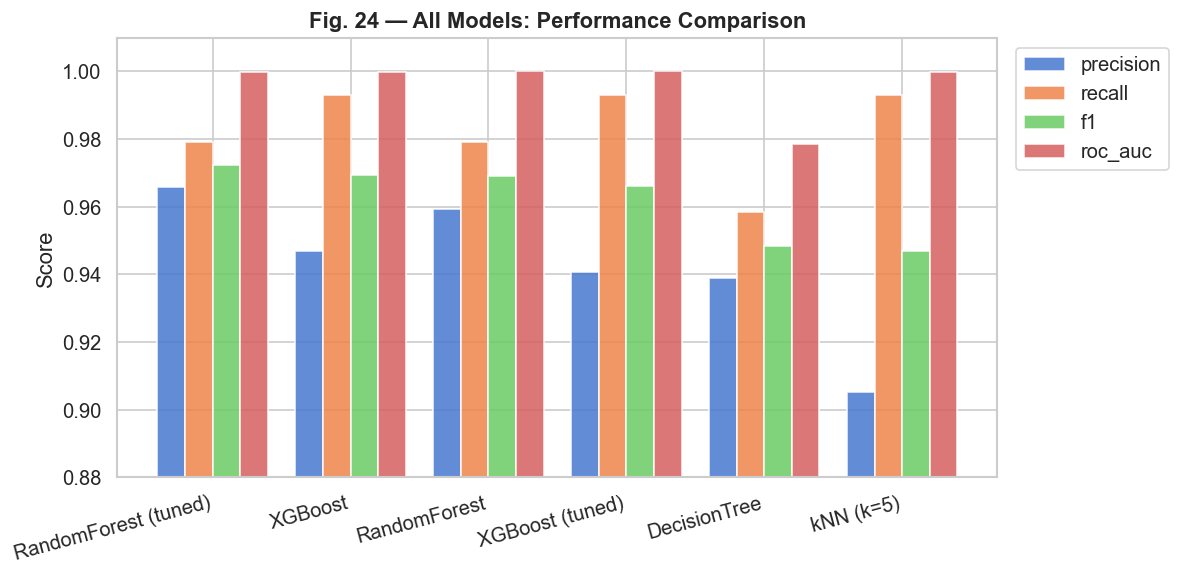

In [11]:
all_results = pd.concat([baseline_df, tuned_df]).sort_values('f1', ascending=False)
print('All models ranked by F1:')
display(all_results)

fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(all_results))
width = 0.2
palette = sns.color_palette('muted', len(metrics))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, all_results[metric], width, label=metric,
           color=palette[i], edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(all_results.index, rotation=15, ha='right')
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Score')
ax.set_title('Fig. 24 — All Models: Performance Comparison', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/model_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Decision Tree Visualisation

One of the Decision Tree's main advantages is interpretability. Printing the top 4 levels of the tree shows which features the model uses first to split the data.

In [12]:
dt_viz = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt_viz.fit(X_train, y_train)

tree_text = export_text(dt_viz, feature_names=list(X_train.columns), max_depth=4)
print('Decision Tree (max_depth=4):')
print(tree_text[:3000])

Decision Tree (max_depth=4):
|--- total_errors <= 1.50
|   |--- error5_count <= 0.50
|   |   |--- volt_mean <= 187.89
|   |   |   |--- error4_count <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- error4_count >  0.50
|   |   |   |   |--- class: 0
|   |   |--- volt_mean >  187.89
|   |   |   |--- error1_count <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- error1_count >  0.50
|   |   |   |   |--- class: 1
|   |--- error5_count >  0.50
|   |   |--- vibration_zscore <= 2.10
|   |   |   |--- class: 0
|   |   |--- vibration_zscore >  2.10
|   |   |   |--- vibration_momentum <= -0.75
|   |   |   |   |--- class: 0
|   |   |   |--- vibration_momentum >  -0.75
|   |   |   |   |--- class: 1
|--- total_errors >  1.50
|   |--- rotate_zscore <= -1.55
|   |   |--- error2_count <= 0.50
|   |   |   |--- vibration_mean_rolling3_std <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- vibration_mean_rolling3_std >  4.50
|   |   |   |   |--- class: 1
|   |   |--- error2_count >  0.50
|  

## 12. Save Best Models

In [13]:
best_k  = pd.DataFrame(knn_results).set_index('k')['f1'].idxmax()
knn_best = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_sc, y_train)

models_to_save = {
    'decision_tree':         trained_baseline['DecisionTree'],
    'random_forest_baseline': trained_baseline['RandomForest'],
    'xgboost_baseline':      trained_baseline['XGBoost'],
    'knn_best':              knn_best,
    'random_forest_tuned':   rf_search.best_estimator_,
    'xgboost_tuned':         xgb_search.best_estimator_,
    'scaler':                scaler,
}

for name, obj in models_to_save.items():
    path = f'{MODELS_DIR}/{name}.joblib'
    joblib.dump(obj, path)
    print(f'Saved: {path}')

Saved: ../models/decision_tree.joblib
Saved: ../models/random_forest_baseline.joblib
Saved: ../models/xgboost_baseline.joblib
Saved: ../models/knn_best.joblib
Saved: ../models/random_forest_tuned.joblib
Saved: ../models/xgboost_tuned.joblib
Saved: ../models/scaler.joblib


## 13. Training Summary

In [14]:
print('=== Training Summary ===')
print(f'Train size        : {len(X_train):,}  ({y_train.sum()} positives)')
print(f'Test size         : {len(X_test):,}   ({y_test.sum()} positives)')
print(f'Imbalance ratio   : ~50:1 (handled via scale_pos_weight / class_weight)')
print()
best_model_name = all_results['f1'].idxmax()
best_f1         = all_results.loc[best_model_name, 'f1']
best_auc        = all_results.loc[best_model_name, 'roc_auc']
print(f'Best model        : {best_model_name}')
print(f'  F1              : {best_f1}')
print(f'  AUC             : {best_auc}')
print()
print('Models saved to models/')
print('Next: notebooks/04_evaluation.ipynb for full evaluation and SMOTE experiment')

=== Training Summary ===
Train size        : 29,280  (574 positives)
Test size         : 7,320   (144 positives)
Imbalance ratio   : ~50:1 (handled via scale_pos_weight / class_weight)

Best model        : RandomForest (tuned)
  F1              : 0.9724
  AUC             : 0.9999

Models saved to models/
Next: notebooks/04_evaluation.ipynb for full evaluation and SMOTE experiment
